> **Strix — Drone Search & Rescue.** Part of the [Strix research repository](../README.md).
> This notebook covers **Phase 2 — YOLOv8 detection (the winning approach)**. Full write-up in [`docs/`](../docs/).


<div class="alert alert-block alert-info" style="font-size:20px; font-family:verdana;">
    <b>Hello friends!</b>
    <br>In this work, I would like to draw your attention to a serious problem. Many people go missing every year, and our technological progress allows literally everyone to make a search drone in their backyard. By gathering a whole team, we can make an autonomous drone to search for missing people in large areas. To show you how useful machine learning can be in the right hands, I made this notebook. I hope you find something new and useful for yourself in this<br>
</div>

![](https://fp-wordpress-assets.s3.amazonaws.com/2022/11/Drone-GIF.gif)

<div class="alert alert-block alert-info" style="font-size:20px; font-family:verdana;">
<b>What will be in this notebook?</b>
<ul style="font-size:20px; font-family:verdana; line-height: 1.7em">
    <li>We will study the work with detection.</li>
    <li>Let's understand the detection architectures.</li>
    <li>Let's work with ultralytics.</li>
    <li>Consider SOTA in detection tasks (YOLOv8).</li>
</ul>
</div>

![](https://upload.wikimedia.org/wikipedia/commons/thumb/8/8c/LizaAlert_logo2020.svg/250px-LizaAlert_logo2020.svg.png)

# Introduction
****

<div style="background-color:#d4f1f4; padding: 20px;">
<p style="font-size:20px; font-family:verdana; line-height: 1.7em">
    <br><b>About LizaAlert</b><br>
    Volunteer search and rescue squad "LizaAlert" is a voluntary non-profit public association engaged in the search for missing people. The detachment was founded on October 15, 2010. According to the PSO, in 2019, 25,255 applications were received, of which 19,051 people were found alive and 2,043 dead by volunteers.</p>
    
<p style="font-size:20px; font-family:verdana; line-height: 1.7em">
    <br><b>History</b><br>
    The organization arose in September 2010, when a group of about five hundred spontaneously gathered volunteers searched for five-year-old Lisa Fomkina and her aunt who disappeared on September 13 in the vicinity of Orekhovo-Zuev near Moscow. The body of the girl was found 10 days later, the aunts the day before, both died of hypothermia. Volunteers who participated in the search came up with the idea to create a search and rescue team: in October 2010, the lizaalert.org website and forum were launched. The detachment was named "LizaAlert": in memory of the deceased girl and English. alert - "alarm signal".</p>
    
<p style="font-size:20px; font-family:verdana; line-height: 1.7em">
    <br><b>End</b><br>
    In hopes of saving more lives, the rescue organization LizaAlert, along with volunteers and other organizations ("Sova"), began collecting data: drone shots of people. This should help to use modern detection architectures after training to search for missing people. Now you know history. You can join and try to improve the detection results or also start collecting data to merge them in the future</p>
</div>

****

<div class="alert alert-block alert-info" style="font-size:20px; font-family:verdana;">
    <b>26 April 2023 | Second showcase</b>
    <br>Storyful
Deputies in Kittitas County, Washington, used a drone to locate a missing three-year-old girl on Tuesday, April 25.

The girl’s family called 911 when she wandered off into rough brush in the Umtanum area, the Kittitas County Sheriff said. Deputies worked with the Kittitas Valley Fire & Rescue and used tracking dogs, aerial drones, and helicopters equipped with infrared cameras to help locate the missing girl, the sheriff’s office said.

This drone footage released by the Kittitas County Sheriff shows the moment the girl was reunited with her grandmother. Credit: Kittitas County Sheriff via Storyful<br>
</div>

![](https://s.yimg.com/uu/api/res/1.2/sIAOjfUF6es8kPAShBSDeQ--~B/Zmk9c3RyaW07aD0zNjA7dz02NDA7c209MTthcHBpZD15dGFjaHlvbg--/https://media.zenfs.com/en/video.storyful.com/266de5349864412111c491822452414e)

<div style="background-color:#d4f1f4; padding: 20px;">
<p style="font-size:20px; font-family:verdana; line-height: 1.7em">
    <br><b> In the picture below you can see the result of the yolo-v8-nano model trained on the LADD dataset 👇</b><br>
    I got pretty good results, so you can too 👌🙃</p>
</div>

![](https://i.ibb.co/0rLfntK/002.png)

<div class="alert alert-block alert-info" style="font-size:20px; font-family:verdana;">
<b>Let's get started ⚡️</b>
<ul style="font-size:20px; font-family:verdana; line-height: 1.7em">
    <li>Feel free to ask questions. I will try to answer everyone 🙃</li>
    <li>I will also be glad to your vote if you found this work useful.</li>
</ul>
</div>

![](https://i.gifer.com/origin/34/34d158fca101006cef587bf1d352295f_w200.gif)

<div class="alert alert-block alert-info" style="font-size:20px; font-family:verdana;">
<b>What is a detection task?</b>
    <br>The detection task consists of two subtasks:<br>
<ul style="font-size:20px; font-family:verdana; line-height: 1.7em">
    <li>Regression, namely the prediction of 4 numbers that are coordinates for the box.</li>
    <li>Classification, namely the prediction of the class that is in this box. That is, detection can be binary and multiclass</li>
</ul>
</div>

![](https://miro.medium.com/v2/resize:fit:1000/1*NLnnf_M4Nlm4p1GAWrWUCQ.gif)

<div style="background-color:#d4f1f4; padding: 20px;">
<p style="font-size:20px; font-family:verdana; line-height: 1.7em">
    <br><b>What is ultralytics?</b><br>
    It's a great machine learning tool. It contains many pre - trained models . It also has a ready-made system for training with management via the CLI (command line interface). This is convenient, since you practically do not need to spend time developing your training system. However, I do not recommend treating this tool as the main one. It deprives you of the ability to control many processes. Use it if you can implement everything yourself, but don't want to waste time. Below I will provide links to sources on this framework</p>
</div>

<div align="center">
  <p>
    <a href="https://ultralytics.com/yolov8" target="_blank">
      <img width="100%" src="https://raw.githubusercontent.com/ultralytics/assets/main/yolov8/banner-yolov8.png"></a>
  </p>
<br>
<div>
    <a href="https://github.com/ultralytics/ultralytics/actions/workflows/ci.yaml"><img src="https://github.com/ultralytics/ultralytics/actions/workflows/ci.yaml/badge.svg" alt="Ultralytics CI"></a>
    <a href="https://zenodo.org/badge/latestdoi/264818686"><img src="https://zenodo.org/badge/264818686.svg" alt="YOLOv8 Citation"></a>
    <a href="https://hub.docker.com/r/ultralytics/ultralytics"><img src="https://img.shields.io/docker/pulls/ultralytics/ultralytics?logo=docker" alt="Docker Pulls"></a>
    <br>
    <a href="https://console.paperspace.com/github/ultralytics/ultralytics"><img src="https://assets.paperspace.io/img/gradient-badge.svg" alt="Run on Gradient"/></a>
    <a href="https://colab.research.google.com/github/ultralytics/ultralytics/blob/main/examples/tutorial.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"></a>
    <a href="https://www.kaggle.com/ultralytics/yolov8"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" alt="Open In Kaggle"></a>
  </div>
  <br>

[Ultralytics](https://ultralytics.com) [YOLOv8](https://github.com/ultralytics/ultralytics) is a cutting-edge, state-of-the-art (SOTA) model that builds upon the success of previous YOLO versions and introduces new features and improvements to further boost performance and flexibility. YOLOv8 is designed to be fast, accurate, and easy to use, making it an excellent choice for a wide range of object detection and tracking, instance segmentation, image classification and pose estimation tasks.

We hope that the resources here will help you get the most out of YOLOv8. Please browse the YOLOv8 <a href="https://docs.ultralytics.com/">Docs</a> for details, raise an issue on <a href="https://github.com/ultralytics/ultralytics">GitHub</a> for support, and join our <a href="https://discord.gg/n6cFeSPZdD">Discord</a> community for questions and discussions!


<div style="background-color:#d4f1f4; padding: 20px;">
<p style="font-size:20px; font-family:verdana; line-height: 1.7em">
    <br><b>As you can see, ultralytics is quite powerful. It can integrate with various tools for monitoring experiments</b><br></p>
</div>

<div class="alert alert-block alert-info" style="font-size:20px; font-family:verdana;">
<b>Dependencies</b>
<ul style="font-size:20px; font-family:verdana; line-height: 1.7em">
    <li>Let's create a virtual environment</li>
    <li>Then we will download the necessary libraries</li>
</ul>
</div>

<div style="background-color:#d4f1f4; padding: 20px;">
    <p style="font-size:20px; font-family:verdana; line-height: 1.7em">
        <b>We will install the ultralitycs framework for training our model, as well as the ClearML tool for monitoring experiments</b>
    </p>
</div>

In [1]:
%%capture
!python -m venv env
!pip install ultralytics
!pip install clearml
!pip install split-folders

<div class="alert alert-block alert-info" style="font-size:20px; font-family:verdana;">
<b>Preparing for data preprocessing ♻</b>
<ul style="font-size:20px; font-family:verdana; line-height: 1.7em">
    <li>Importing libraries.</li>
    <li>Let's prepare the functions for preprocessing.</li>
    <li>Let's do the preprocessing.</li>
</ul>
</div>

# Libraires for data preparation
**And now we import all the necessary libraries. To prepare the data, we only need a couple of libraries. We will do all the rest of the work using the CLI, which is built into the frameworks we need.**

In [2]:
import os
import shutil
import splitfolders
import pandas as pd
import numpy as np
from tqdm import tqdm
from colorama import Fore

## Pathes

In [3]:
IMAGE_PATH = "../input/lacmus-drone-dataset-ladd-v40/images/images" # The path to the folder with images.
TARGET_PATH = "../input/lacmus-drone-dataset-ladd-v40/annotation/annotation/YOLO-format" # The path to the folder with the annotation (labels). 

<div class="alert alert-block alert-info" style="font-size:20px; font-family:verdana;">
<b>Helper functions for data preparation</b>
<ul style="font-size:20px; font-family:verdana; line-height: 1.7em">
    <li>create_dataset() - Creates a dataframe with columns of paths paths to files with annotations and images</li>
    <li>prepare_dirs() - Creates folders in which files with images and their annotation in YOLO format will be extracted</li>
    <li>copy_dirs() - Copies files files with images and their angotation in YOLO format to separate folders</li>
    <li>finalizing_preparation() - Completes data processing. Checks the integrity of the dataset. Removes garbage after preprocessing</li>
</ul>
</div>

<div style="background-color:#d4f1f4; padding: 20px;">
    <p style="font-size:20px; font-family:verdana; line-height: 1.7em">
        <b>Creates a dataframe with columns of paths paths to files with annotations and images</b>
    </p>
</div>

In [4]:
def create_dataset(data_path: str, target_path: str) -> pd.DataFrame:
    assert isinstance(data_path, str) 
    assert isinstance(target_path, str)
    
    dict_paths = {
        "image": [],
        "annotation": []
    }
    
    for dir_name, _, filenames in os.walk(data_path):
        for filename in tqdm(filenames):
            name = filename.split('.')[0]
            dict_paths["image"].append(f"{data_path}/{name}.jpg")
            dict_paths["annotation"].append(f"{target_path}/{name}.txt")

    
    dataframe = pd.DataFrame(
        data=dict_paths,
        index=np.arange(0, len(dict_paths["image"]))
    )
    
    return dataframe

<div style="background-color:#d4f1f4; padding: 20px;">
    <p style="font-size:20px; font-family:verdana; line-height: 1.7em">
        <b>Creates folders in which files with images and their annotation in YOLO format will be extracted</b>
    </p>
</div>

In [5]:
def prepare_dirs(dataset_path: str,
                 annotation_path: str,
                 images_path: str) -> None:
    if not os.path.exists(dataset_path):
        os.mkdir(path=dataset_path)
        os.mkdir(path=annotation_path)
        os.mkdir(path=images_path)

<div style="background-color:#d4f1f4; padding: 20px;">
    <p style="font-size:20px; font-family:verdana; line-height: 1.7em">
        <b>Copies files files with images and their angotation in YOLO format to separate folders</b>
    </p>
</div>

In [6]:
def copy_dirs(dataframe: pd.DataFrame, 
             data_path: str,
             target_path: str) -> None:
    
    assert isinstance(dataframe, pd.DataFrame)
    assert isinstance(data_path, str) 
    assert isinstance(target_path, str)
    
    for i in tqdm(range(len(dataframe))):
        image_path, annotation_path = dataframe.iloc[i]
        shutil.copy(image_path, data_path)
        shutil.copy(annotation_path, target_path)

<div style="background-color:#d4f1f4; padding: 20px;">
    <p style="font-size:20px; font-family:verdana; line-height: 1.7em">
        <b>Completes data processing. Checks the integrity of the dataset. Removes garbage after preprocessing</b>
    </p>
</div>

In [7]:
def finalizing_preparation(dataset_path: str, ladd_path: str):
    assert os.path.exists(f"{dataset_path}")
    
    example_structure = [
        "dataset", 
        "train", "labels", "images",
        "test","labels", "images",
        "val", "labels", "images"
    ]
    
    dir_bone = (
        dirname.split("/")[-1]
        for dirname, _, filenames in os.walk('/kaggle/working/dataset')
        if dirname.split("/")[-1] in example_structure
    )
    
    try:
        print("\n~ Lacmus Dataset Structure ~\n")
        print(
        f"""
      ├── {next(dir_bone)}
      │   │
      │   ├── {next(dir_bone)}
      │   │   └── {next(dir_bone)}
      │   │   └── {next(dir_bone)}
      │   │        
      │   ├── {next(dir_bone)}
      │   │   └── {next(dir_bone)}
      │   │   └── {next(dir_bone)}
      │   │
      │   ├── {next(dir_bone)}
      │   │   └── {next(dir_bone)}
      │   │   └── {next(dir_bone)}
        """
        )
    except StopIteration as e:
        print(e)
    else:
        print(Fore.GREEN + "-> Success")
    finally:
        os.system(f"rm -rf {ladd_path}")

<div class="alert alert-block alert-info" style="font-size:20px; font-family:verdana;">
<b>Data preparation. What do we need to do?</b>
    <br>We will use the YOLO format. The YOLO annotation is located in files with the txt extension<br>
<ul style="font-size:20px; font-family:verdana; line-height: 1.7em">
    <li>Create a dataframe with the columns 'image' and 'annotation', they will store the paths to the files with pictures and their annotation.</li>
    <li>Create folders where we extract annotations in YOLO format and images</li>
    <li>Then copy the files with pictures and their annotation to these folders</li>
    <li>Use the library to split the dataset into training, test and validation samples. This format is not just convenient, but necessary for working with the ultralytics framework</li>
    <li>Finish preprocessing. Check how the processes went</li>
</ul>
</div>

<div style="background-color:#d4f1f4; padding: 20px;">
    <p style="font-size:20px; font-family:verdana; line-height: 1.7em">
        <b>Create a dataframe with the columns 'image' and 'annotation', they will store the paths to the files with pictures and their annotation.</b>
    </p>
</div>

In [8]:
df = create_dataset(
    data_path=IMAGE_PATH,
    target_path=TARGET_PATH
)

100%|██████████| 1365/1365 [00:00<00:00, 443437.76it/s]


In [9]:
dataset_path = "../working/dataset"
ladd_path = "../working/ladd"
annotation_path = "../working/ladd/labels"
image_path = "../working/ladd/images"

<div style="background-color:#d4f1f4; padding: 20px;">
    <p style="font-size:20px; font-family:verdana; line-height: 1.7em">
        <b>Create folders where we extract annotations in YOLO format and images</b>
    </p>
</div>

In [10]:
prepare_dirs(
    dataset_path=ladd_path,
    annotation_path=annotation_path,
    images_path=image_path
)

<div style="background-color:#d4f1f4; padding: 20px;">
    <p style="font-size:20px; font-family:verdana; line-height: 1.7em">
        <b>Then copy the files with pictures and their annotation to these folders</b>
    </p>
</div>


In [11]:
copy_dirs(
    dataframe=df, 
    data_path=image_path,
    target_path=annotation_path
)

100%|██████████| 1365/1365 [01:14<00:00, 18.41it/s]


<div style="background-color:#d4f1f4; padding: 20px;">
    <p style="font-size:20px; font-family:verdana; line-height: 1.7em">
        <b>Use the library to split the dataset into training, test and validation samples.<br>This format is not just convenient, but necessary for working with the ultralytics framework</b><br>
    </p>
</div>

In [12]:
splitfolders.ratio(
    input=ladd_path,
    output=dataset_path,
    seed=42,
    ratio=(0.80, 0.10, 0.10),
    group_prefix=None,
    move=True
) 

Copying files: 2730 files [00:00, 15132.69 files/s]


<div style="background-color:#d4f1f4; padding: 20px;">
    <p style="font-size:20px; font-family:verdana; line-height: 1.7em">
        <b>Finish preprocessing. <br>Check how the processes went</b><br>
    </p>
</div>

In [13]:
finalizing_preparation(
    dataset_path,
    ladd_path
)


~ Lacmus Dataset Structure ~


      ├── dataset
      │   │
      │   ├── train
      │   │   └── images
      │   │   └── labels
      │   │        
      │   ├── val
      │   │   └── images
      │   │   └── labels
      │   │
      │   ├── test
      │   │   └── images
      │   │   └── labels
        
-> Success


<div style="background-color:#d4f1f4; padding: 20px;">
    <p style="font-size:20px; font-family:verdana; line-height: 1.7em">
        <br><b>And so we successfully prepared our data ✅</b><br>
        Now we can move on to learning. However, how do we track our experiments and visualize our metrics? Consider this question below
    </p>
</div>

# ClearML Logging and Automation 🌟 NEW

[ClearML](https://cutt.ly/yolov5-notebook-clearml) is completely integrated into YOLOv5 to track your experimentation, manage dataset versions and even remotely execute training runs. To enable ClearML (check cells above):

- `pip install clearml`
- run `clearml-init` to connect to a ClearML server (**deploy your own [open-source server](https://github.com/allegroai/clearml-server)**, or use our [free hosted server](https://cutt.ly/yolov5-notebook-clearml))

You'll get all the great expected features from an experiment manager: live updates, model upload, experiment comparison etc. but ClearML also tracks uncommitted changes and installed packages for example. Thanks to that ClearML Tasks (which is what we call experiments) are also reproducible on different machines! With only 1 extra line, we can schedule a YOLOv5 training task on a queue to be executed by any number of ClearML Agents (workers).

You can use ClearML Data to version your dataset and then pass it to YOLOv5 simply using its unique ID. This will help you keep track of your data without adding extra hassle. Explore the [ClearML Tutorial](https://github.com/ultralytics/yolov5/tree/master/utils/loggers/clearml) for details!

<a href="https://cutt.ly/yolov5-notebook-clearml">
<img alt="ClearML Experiment Management UI" src="https://github.com/thepycoder/clearml_screenshots/raw/main/scalars.jpg" width="1280"/></a>

# Weights and biases
 <p align='center'> 
 <a href="https://pypi.python.org/pypi/wandb"><img src="https://img.shields.io/pypi/v/wandb" /></a> 
 <a href="https://anaconda.org/conda-forge/wandb"><img src="https://img.shields.io/conda/vn/conda-forge/wandb" /></a> 
 <a href="https://circleci.com/gh/wandb/wandb"><img src="https://img.shields.io/circleci/build/github/wandb/wandb/main" /></a> 
 <a href="https://codecov.io/gh/wandb/wandb"><img src="https://img.shields.io/codecov/c/gh/wandb/wandb" /></a> 
 </p> 
 <p align='center'> 
 <a href="https://colab.research.google.com/github/wandb/examples/blob/master/colabs/intro/Intro_to_Weights_%26_Biases.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" /></a> 
 </p> 
  
 Use W&B to build better models faster. Track and visualize all the pieces of your machine learning pipeline, from datasets to production machine learning models. Get started with W&B today, [sign up for a free account!](https://wandb.com?utm_source=github&utm_medium=code&utm_campaign=wandb&utm_content=readme) 
  
 🎓 W&B is free for students, educators, and academic researchers. For more information, visit [https://wandb.ai/site/research](https://wandb.ai/site/research?utm_source=github&utm_medium=code&utm_campaign=wandb&utm_content=readme). 
  
 Want to use Weights & Biases for seamless collaboration between your ML or Data Science team? Looking for Production-grade MLOps at scale? Sign up to one of [our plans](https://wandb.ai/site/pricing) or [contact the Sales Team](https://wandb.ai/site/contact).


## Local Logging

Training results are automatically logged with [Tensorboard](https://www.tensorflow.org/tensorboard) and [CSV](https://github.com/ultralytics/yolov5/pull/4148) loggers to `runs/train`, with a new experiment directory created for each new training as `runs/train/exp2`, `runs/train/exp3`, etc.

This directory contains train and val statistics, mosaics, labels, predictions and augmentated mosaics, as well as metrics and charts including precision-recall (PR) curves and confusion matrices. 

<img alt="Local logging results" src="https://user-images.githubusercontent.com/26833433/183222430-e1abd1b7-782c-4cde-b04d-ad52926bf818.jpg" width="1280"/>

# Let's start learning ⚡️
**First we need to create a configuration file. This file will contain paths to our data, as well as classes**

In [14]:
import yaml
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

In [15]:
config = {
    "path": "/kaggle/working/dataset",
    "train": "/kaggle/working/dataset/train/images",
    "val": "/kaggle/working/dataset/val/images",
    "predict": "/kaggle/working/test/train/images",
    "nc": 1,
    "names": ["human"]
}

with open("config.yaml", "w") as f:
    yaml.dump(config, f)

with open("config.yaml", "r") as f:
    print(f.read())

names:
- human
nc: 1
path: /kaggle/working/dataset
predict: /kaggle/working/test/train/images
train: /kaggle/working/dataset/train/images
val: /kaggle/working/dataset/val/images



# YOLOv8 Architecture: A Deep Dive
<div class="alert alert-block alert-info" style="font-size:20px; background-color: #eec4ff; font-family:verdana; color: #511b66; border: 2px #511b66 solid">
YOLOv8 does not yet have a published paper, so we lack direct insight into the direct research methodology and ablation studies done during its creation. With that said, we analyzed the repository and information available about the model to start documenting what's new in YOLOv8.

If you want to peer into the code yourself, check out the YOLOv8 repository and you view this code differential to see how some of the research was done.

Here we provide a quick summary of impactful modeling updates and then we will look at the model's evaluation, which speaks for itself.

The following image made by GitHub user RangeKing shows a detailed visualisation of the network's architecture.
</div>

![](https://blog.roboflow.com/content/images/size/w1000/2023/01/image-16.png)

# Training
<div class="alert alert-block alert-info" style="font-size:20px; background-color: #eec4ff; font-family:verdana; color: #511b66; border: 2px #511b66 solid">
    <b>Finally, we can start learning 🥳</b>
    <br>From this moment begins our greedy search. We select hypermaparmeters, train, and then check whether the hypothesis was correct using the resulting metrics. This stage is one of the most interesting<br>
</div>

In [18]:
def main():
    model = YOLO("yolov8n.pt")
    model.train(
        # Project
        project="Polar-Owl",
        name="yolov8n",

        # Random Seed parameters
        deterministic=True,
        seed=42,

        # Data & model parameters
        data="/kaggle/working/config.yaml", 
        save=True,
        save_period=5,
        pretrained=True,
        imgsz=1280,

        # Training parameters
        epochs=20,
        batch=4,
        workers=8,
        val=True,
        device=0,

        # Optimization parameters
        lr0=0.0195,
        patience=3,
        optimizer="SGD",
        momentum=0.957,
        weight_decay=0.0005,
        close_mosaic=5,
    )

<div class="alert alert-block alert-info" style="font-size:20px; background-color: #eec4ff; font-family:verdana; color: #511b66; border: 2px #511b66 solid">
    <b>Please follow the <a href=https://wandb.ai/site>link</a>. Sign up and then paste your API key into the box that pops up below. Do not disclose your key to anyone. Here it is required so that you can track the training</b>
</div>

In [19]:
if __name__ == '__main__':
    main()

Ultralytics YOLOv8.0.124 🚀 Python-3.7.12 torch-1.13.0 CUDA:0 (Tesla P100-PCIE-16GB, 16281MiB)
WARNING ⚠️ Upgrade to torch>=2.0.0 for deterministic training.
yolo/engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/kaggle/working/config.yaml, epochs=20, patience=3, batch=4, imgsz=1280, save=True, save_period=5, cache=False, device=0, workers=8, project=Polar-Owl, name=yolov8n, exist_ok=False, pretrained=True, optimizer=SGD, verbose=True, seed=42, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=5, resume=False, amp=True, fraction=1.0, profile=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, show=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, vid_stride=1, line_width=None, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, boxes=T

  0%|          | 0.00/755k [00:00<?, ?B/s]

Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

  ········································


wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


AMP: running Automatic Mixed Precision (AMP) checks with YOLOv8n...
AMP: checks passed ✅
train: Scanning /kaggle/working/dataset/train/labels... 1092 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1092/1092 [00:05<00:00, 187.52it/s]
train: New cache created: /kaggle/working/dataset/train/labels.cache
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01), CLAHE(p=0.01, clip_limit=(1, 4.0), tile_grid_size=(8, 8))
val: Scanning /kaggle/working/dataset/val/labels... 136 images, 0 backgrounds, 0 corrupt: 100%|██████████| 136/136 [00:01<00:00, 124.05it/s]
val: New cache created: /kaggle/working/dataset/val/labels.cache
Plotting labels to Polar-Owl/yolov8n/labels.jpg... 
optimizer: SGD(lr=0.0195, momentum=0.957) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
Image sizes 1280 train, 1280 val
Using 2 dataloader workers
Logging results to Polar-Owl/yolov8n
Starting training for 20 epochs...

      Epoch

<div style="background-color:#d4f1f4; padding: 20px;">
        <br><b>WANDB easily allows you to cool down the load on the server</b><br></p>
</div>

![2023-05-06_17-46-28.png](https://i.ibb.co/mzkYy2b/2023-05-06-17-46-28.png)

<div style="background-color:#d4f1f4; padding: 20px;">
    <p style="font-size:20px; font-family:verdana; line-height: 1.7em">
        <br><b>And also to settle metrics</b><br></p>
    In general, this experiment control system can do quite a lot of things, so I advise you to familiarize yourself with their documentation
</div>

![2023-05-06_17-45-15.png](https://i.ibb.co/YRCGqnP/2023-05-06-17-45-15.png)

# Predict

<div class="alert alert-block alert-info" style="font-size:20px; font-family:verdana;">
<b>The training has come to an end and now it is time to look at the results of the work of the neural network</b>
<ul style="font-size:20px; font-family:verdana; line-height: 1.7em">
    <li>Choose any picture</li>
    <li>Processing the results</li>
    <li>Displaying the image</li>
</ul>
</div>

<div class="alert alert-block alert-info" style="font-size:20px; font-family:verdana;">
    <b>Choose any picture</b>
</div>

In [20]:
!ls ../working/dataset/test/images

1009.jpg  1168.jpg  1312.jpg  257.jpg  437.jpg	616.jpg  834.jpg  97.jpg
1018.jpg  117.jpg   1351.jpg  258.jpg  442.jpg	621.jpg  846.jpg  973.jpg
1043.jpg  1176.jpg  1364.jpg  261.jpg  452.jpg	632.jpg  848.jpg  980.jpg
1046.jpg  1183.jpg  156.jpg   263.jpg  468.jpg	68.jpg	 856.jpg  984.jpg
1052.jpg  1186.jpg  159.jpg   267.jpg  47.jpg	690.jpg  859.jpg  988.jpg
1056.jpg  12.jpg    161.jpg   277.jpg  470.jpg	700.jpg  869.jpg  989.jpg
1077.jpg  1202.jpg  166.jpg   282.jpg  473.jpg	709.jpg  87.jpg   991.jpg
1081.jpg  1208.jpg  172.jpg   302.jpg  48.jpg	745.jpg  88.jpg   992.jpg
1084.jpg  1227.jpg  174.jpg   31.jpg   5.jpg	754.jpg  883.jpg  993.jpg
110.jpg   1252.jpg  176.jpg   35.jpg   505.jpg	759.jpg  893.jpg  995.jpg
1114.jpg  1254.jpg  181.jpg   351.jpg  509.jpg	76.jpg	 91.jpg   998.jpg
1119.jpg  1260.jpg  19.jpg    368.jpg  543.jpg	763.jpg  922.jpg
1125.jpg  128.jpg   192.jpg   390.jpg  548.jpg	775.jpg  929.jpg
1129.jpg  1284.jpg  199.jpg   397.jpg  549.jpg	788.jpg  932.jpg
1142.jpg  12

<div class="alert alert-block alert-info" style="font-size:20px; font-family:verdana;">
    <b>Processing the results</b>
    <br>Keep in mind that matplotlib has special features for drawing shapes<br>
</div>

In [24]:
model = YOLO("/kaggle/working/Polar-Owl/yolov8n/weights/best.pt")

In [25]:
history = model.predict("../working/dataset/test/images/302.jpg")[0]
image = history.orig_img


image 1/1 /kaggle/working/../working/dataset/test/images/302.jpg: 960x1280 4 humans, 15.8ms
Speed: 9.8ms preprocess, 15.8ms inference, 2.7ms postprocess per image at shape (1, 3, 960, 1280)


<div class="alert alert-block alert-info" style="font-size:20px; font-family:verdana;">
    <b>First human</b>
</div>

In [26]:
Xmin1, Ymin1, Xmax1, Ymax1, conf1, _ = history.boxes.data[0].cpu().numpy()

W1 = Xmax1 - Xmin1 
H1 = Ymax1 - Ymin1

<div class="alert alert-block alert-info" style="font-size:20px; font-family:verdana;">
    <b>Second human</b>
</div>

In [27]:
Xmin2, Ymin2, Xmax2, Ymax2, conf2, _ = history.boxes.data[1].cpu().numpy()

W2 = Xmax2 - Xmin2 
H2 = Ymax2 - Ymin2

<div class="alert alert-block alert-info" style="font-size:20px; font-family:verdana;">
    <b>Displaying the image</b>
    <br>As you can see, the model did well. I've gotten the best results by training the model for 100 epochs, so feel free to experiment.<br>
</div>

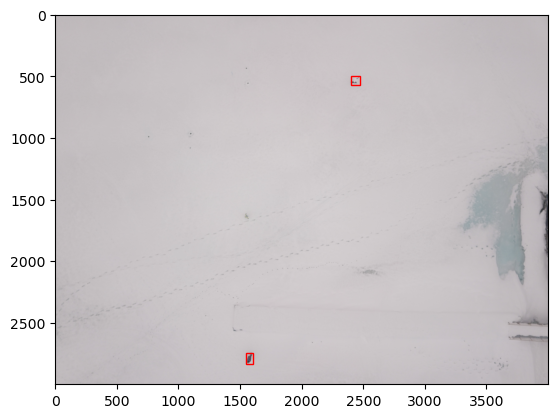

In [28]:
plt.imshow(image)

plt.gca().add_patch(
    Rectangle([Xmin1, Ymin1], W1, H1,
              edgecolor='red',
              facecolor='none',
              lw=1)
)

plt.gca().add_patch(
    Rectangle([Xmin2, Ymin2], W2, H2,
              edgecolor='red',
              facecolor='none',
              lw=1)
)

plt.show()

<div class="alert alert-block alert-info" style="font-size:20px; font-family:verdana;">
<b>Is this the only way to get the output of a neural network?</b>
    <br>We made such a forecast so that you understand what the output of YOLO models is like.<br>
     However, we can make it much easier
</div>


image 1/1 /kaggle/working/../working/dataset/test/images/302.jpg: 960x1280 3 humans, 9.7ms
Speed: 16.6ms preprocess, 9.7ms inference, 1.4ms postprocess per image at shape (1, 3, 960, 1280)


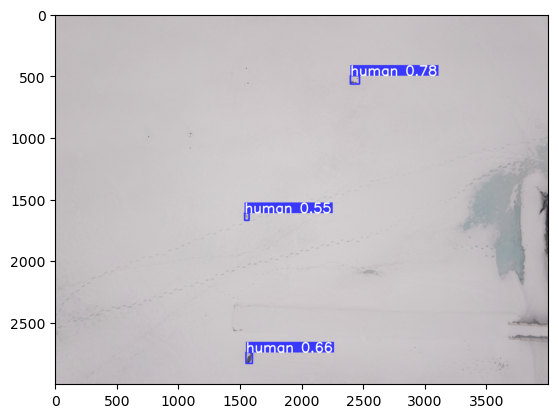

In [30]:
history = model.predict("../working/dataset/test/images/302.jpg", conf=0.5)[0]
image = history.plot()
plt.imshow(image)
plt.show()

# Let's build the graphs 

<div class="alert alert-block alert-info" style="font-size:20px; font-family:verdana;">
    <b>Batches</b>
</div>

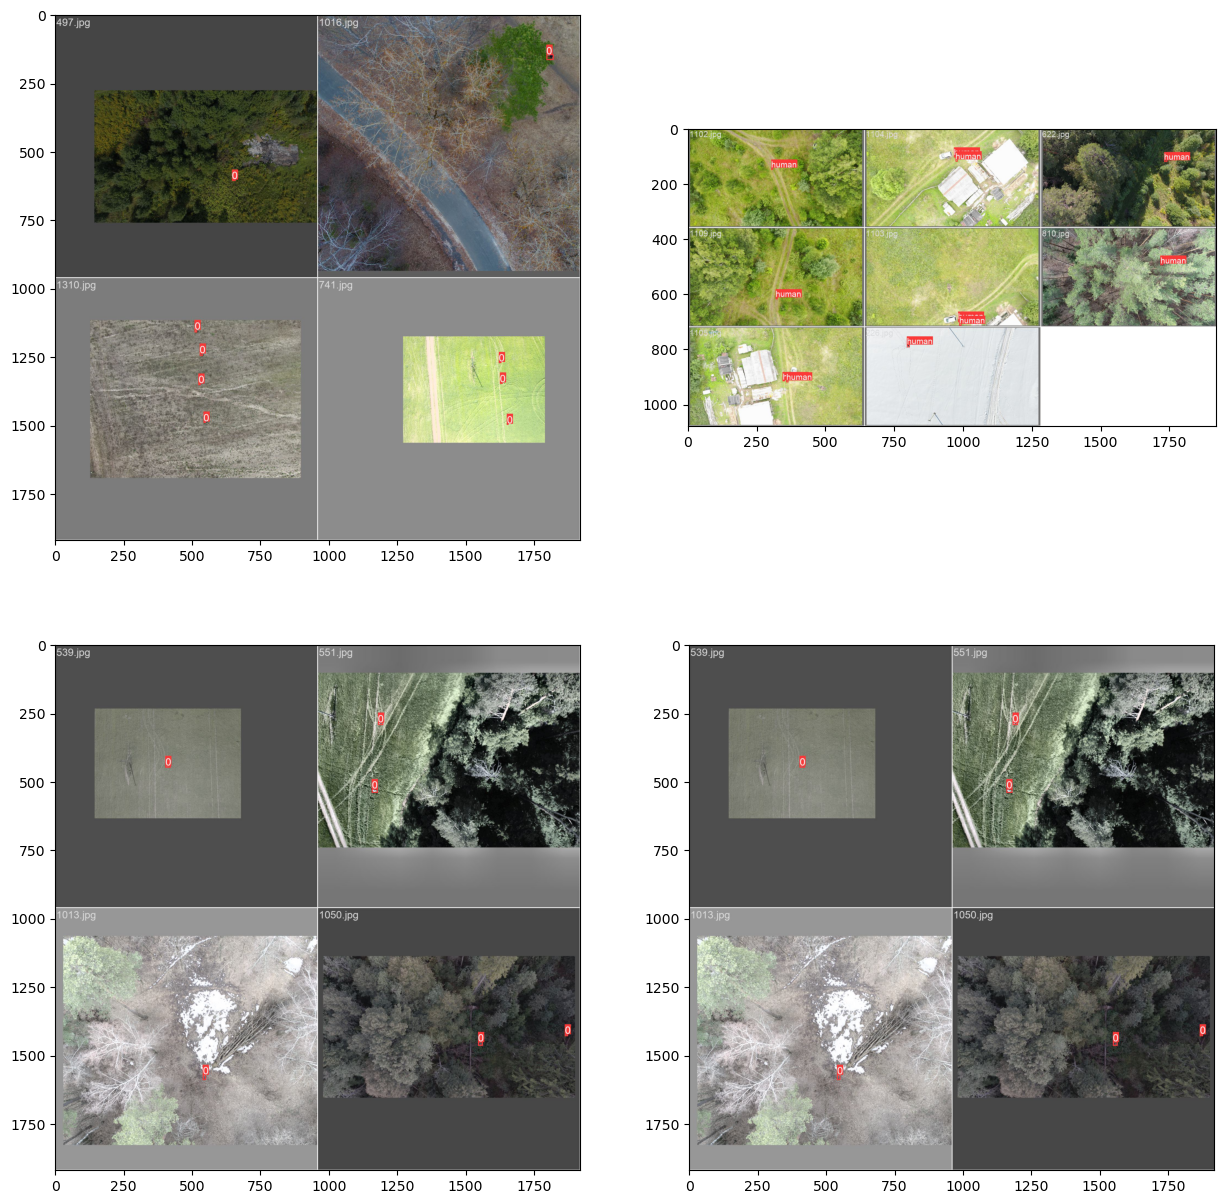

In [53]:
batch1 = Image.open("/kaggle/working/Polar-Owl/yolov8n/train_batch4097.jpg")
batch2 = Image.open("/kaggle/working/Polar-Owl/yolov8n/val_batch0_labels.jpg")
batch3 = Image.open("/kaggle/working/Polar-Owl/yolov8n/train_batch4095.jpg")
batch4 = Image.open("/kaggle/working/Polar-Owl/yolov8n/train_batch4095.jpg")

fig, axes = plt.subplots(2, 2)
fig.set_size_inches(15, 15)
axes[0][0].imshow(batch1)
axes[0][1].imshow(batch2)
axes[1][0].imshow(batch3)
axes[1][1].imshow(batch4)
plt.show()

<div class="alert alert-block alert-info" style="font-size:20px; font-family:verdana;">
    <b>Losses & Recall & Precision & mAP</b>
</div>

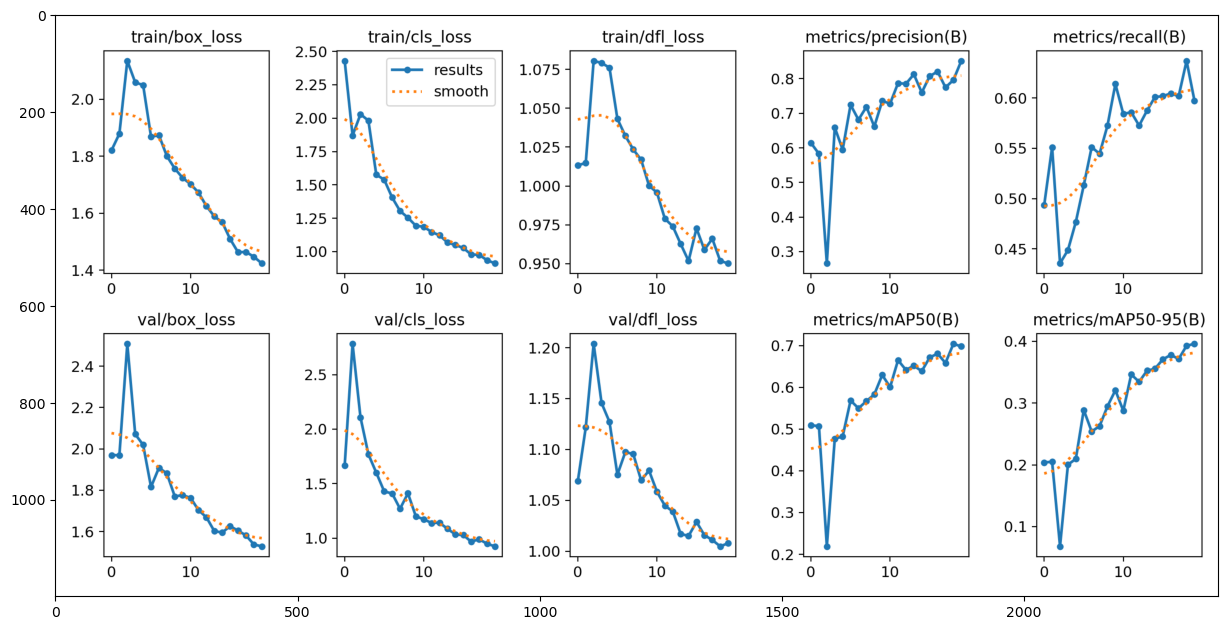

In [33]:
results = Image.open("/kaggle/working/Polar-Owl/yolov8n/results.png")
plt.figure(figsize=(15, 20))
plt.imshow(results)
plt.show()

<div class="alert alert-block alert-info" style="font-size:20px; font-family:verdana;">
    <b>F1-Curve</b>
</div>

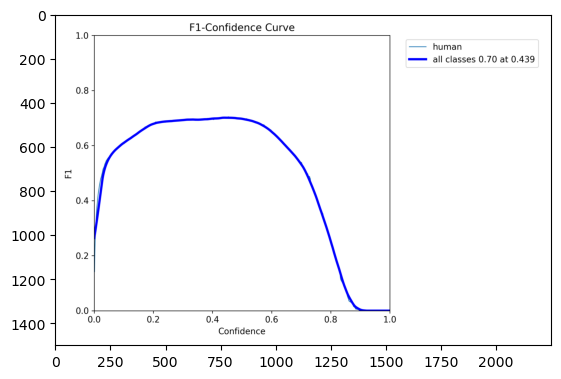

In [34]:
F1_curve = Image.open("/kaggle/working/Polar-Owl/yolov8n/F1_curve.png")
plt.imshow(F1_curve)
plt.show()

<div class="alert alert-block alert-info" style="font-size:20px; font-family:verdana;">
    <b>PR-Curve</b>
</div>

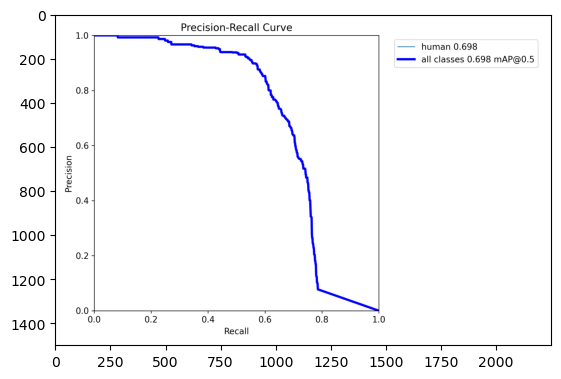

In [35]:
PR_curve = Image.open("/kaggle/working/Polar-Owl/yolov8n/PR_curve.png")
plt.imshow(PR_curve)
plt.show()

<div class="alert alert-block alert-info" style="font-size:20px; font-family:verdana;">
    <b>P-Curve</b>
</div>

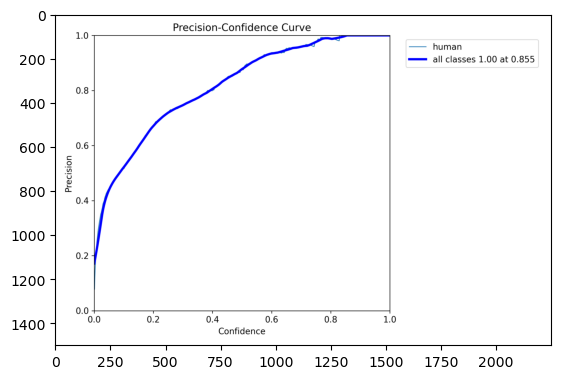

In [36]:
P_curve = Image.open("/kaggle/working/Polar-Owl/yolov8n/P_curve.png")
plt.imshow(P_curve)
plt.show()

<div class="alert alert-block alert-info" style="font-size:20px; font-family:verdana;">
    <b>R-Curve</b>
</div>

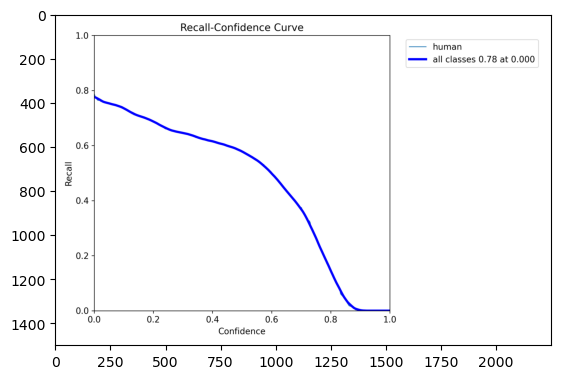

In [37]:
R_curve = Image.open("/kaggle/working/Polar-Owl/yolov8n/R_curve.png")
plt.imshow(R_curve)
plt.show()

<div class="alert alert-block alert-info" style="font-size:20px; font-family:verdana;">
    <b>Thanks a lot for making it to the end</b>
    <br>I hope you have found this work useful. Good luck 🙃<br>
</div>

![](https://i.pinimg.com/originals/01/92/45/0192453508d17587a87afeaa7cb50d6e.gif)